# Stock Price Predictor using Machine Learning

Initial imports

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf       # yahoo finance API from which we will get our data
import matplotlib.pyplot as plt     # Visualization

import torch        # Deep learning library
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler        # scale and...
from sklearn.metrics import root_mean_squared_error     # ... evaluation

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2020-01-02  296.125275  296.143523  293.992323  294.912966  59151200
2020-01-03  293.882996  295.004175  292.688907  292.743596  77709700
2020-01-06  295.004059  295.086092  292.014249  292.132751  55653900
2020-01-07  294.174622  294.912950  293.727958  294.438942  40496400
2020-01-08  295.742554  296.954863  294.120050  294.366150  68296000
...                ...         ...         ...         ...       ...
2026-09-01  761.780029  764.669983  759.479980  762.010010  41126300
2026-09-02  765.159973  766.429993  761.729980  762.450012  29566200
2026-09-03  773.169983  774.030029  767.450012  767.900024  43531600
2026-09-04  770.190002  772.869995  769.000000  772.010010  34054200
2026-09-08  765.960022  769.700012  765.140015  769.070007  44708800

[1679 rows x 5 columns]


<Axes: xlabel='Date'>

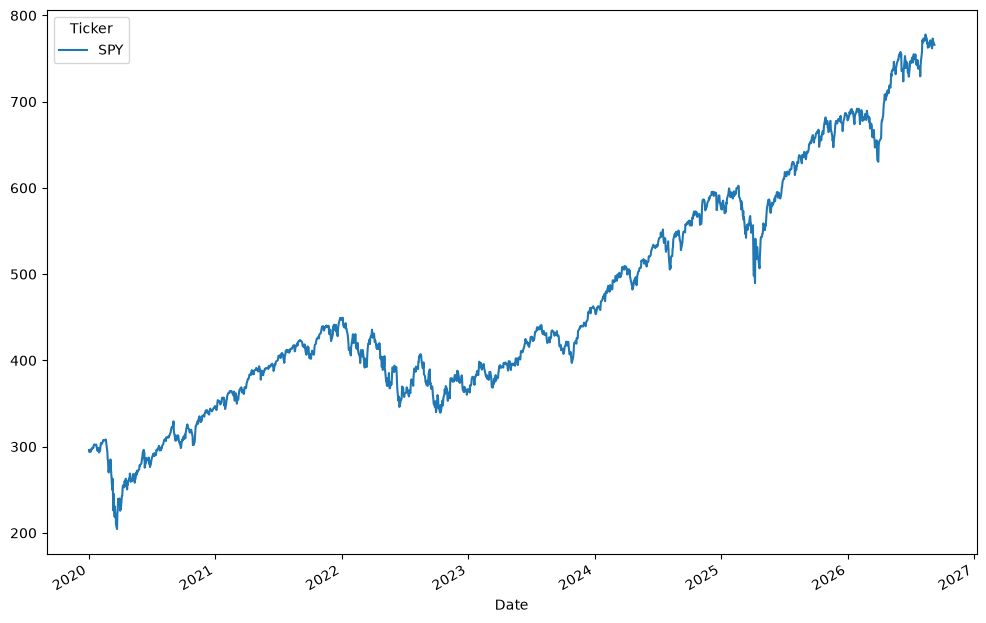

In [ ]:
# Ideally, we want to use a CUDA supported GPU, but if unavailable, we can use any CPU
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Next we want to take our ticker, in this case SPY, and load the ticker data into a dataframe starting from january of 2020
ticker = 'SPY'
df = yf.download(ticker, '2020-01-01')
print(df)

# Plotting the Close prices of SPY
df.Close.plot(figsize=(12, 8))

We've taken our data from the yfinance import, loaded it into a dataframe and plotted the points. Our plan is to cut 80% of that data to train our model, and use it to predict or test it against the last 20% or so.

In [6]:
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df['Close'])
df.Close

Ticker,SPY
Date,
2020-01-02,-1.280793
2020-01-03,-1.297615
2020-01-06,-1.289205
2020-01-07,-1.295427
2020-01-08,-1.283664
...,...
2026-09-01,2.212743
2026-09-02,2.238100
2026-09-03,2.298195
